In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from package.data import *

# data

In [2]:
df = pd.read_csv('../data/format_data.csv')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65366 entries, 0 to 65365
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date_onset   65366 non-null  object 
 1   date_report  65366 non-null  object 
 2   CLASSI_FIN   64061 non-null  float64
 3   EVOLUCAO     62549 non-null  float64
 4   CO_MUN_RES   65366 non-null  int64  
 5   age_col      65366 non-null  int64  
 6   fx_etaria    65366 non-null  int64  
 7   Delay        65366 non-null  int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 4.0+ MB


In [52]:
df.head()

,date_onset,date_report,CLASSI_FIN,EVOLUCAO,CO_MUN_RES,age_col,fx_etaria,Delay
0,2020-02-10,2020-03-02,4.0,1.0,310620,59,7,3
1,2020-01-20,2020-02-03,4.0,1.0,310620,79,9,2
2,2020-03-30,2020-04-13,4.0,1.0,310620,72,9,2
3,2020-03-23,2020-03-30,4.0,1.0,310620,82,10,1
4,2020-03-16,2020-04-13,4.0,1.0,310620,50,7,4


columns:
  - date_onset: date of contraction
  - date_report: date of reported
  - CLASSI_FIN: Final classification of case
  - EVOLUCAO: Case evolution
  - CO_MUM_RES: Municipality code
  - age_col: Age
  - fx_eteria: Age bracket
  - Delay: delay between contraction and report in weeks

In [53]:
print(f"{df['date_onset'].min()} min")
print(f"{df['date_onset'].max()} max")

2019-12-23 min
2022-03-21 max


In [54]:
print(f"{df['date_report'].min()} min")
print(f"{df['date_report'].max()} max")

2019-12-30 min
2022-03-28 max


# processing

In [55]:
data = df.copy()
data = data.rename(columns={'Delay': 'delay'}).drop(columns=['CLASSI_FIN', 'EVOLUCAO', 'CO_MUN_RES'])

In [56]:
data['date_onset']  = pd.to_datetime(data['date_onset'])
data['date_report'] = pd.to_datetime(data['date_report'])

In [57]:
print(data['delay'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

0.50     3.0
0.75     5.0
0.90     9.0
0.95    12.0
0.99    25.0
Name: delay, dtype: float64


will go with 10

In [58]:
D = 10

n_before = len(data)
data = data[data['delay'] <= D].copy()
print(f"\nKept {len(data)} / {n_before} cases with Delay ≤ {D} "
      f"({100*len(data)/n_before:.1f}%)")


Kept 60749 / 65366 cases with Delay ≤ 10 (92.9%)


In [59]:
data = data.rename(columns={'delay':'d', 'date_onset':'date'})

In [65]:
counts = (data.groupby(['date', 'd']).size().reset_index(name='n_td'))

all_dates = pd.date_range(counts['date'].min(), counts['date'].max(), freq='W-MON')
grid = pd.MultiIndex.from_product([all_dates, range(D + 1)],names=['date', 'd']).to_frame(index=False)
data = grid.merge(counts, on=['date', 'd'], how='left').fillna({'n_td': 0})

In [61]:
data['t'] = data['date'].rank(method='dense').astype(int)
data['week_of_year'] = data['date'].dt.isocalendar().week.astype(int)
data.loc[data['week_of_year'] == 53, 'week_of_year'] = 52

In [62]:
data = data[['date', 't', 'd', 'week_of_year', 'n_td']]
data['n_td'] = data['n_td'].astype(int)

In [63]:
data

,date,t,d,week_of_year,n_td
0,2019-12-23,1,0,52,0
1,2019-12-23,1,1,52,1
2,2019-12-23,1,2,52,0
3,2019-12-23,1,3,52,1
4,2019-12-23,1,4,52,0
...,...,...,...,...,...
1293,2022-03-21,118,6,12,0
1294,2022-03-21,118,7,12,0
1295,2022-03-21,118,8,12,0
1296,2022-03-21,118,9,12,0


In [64]:
og_data = data.copy()
og_data.to_csv('../data/untrimmed_data.csv')

# exploration

Question:
  - Which date shall I pick as current?
    - Ideally I want to pick a date where an outbreak happens to test the nowcasting

<Axes: xlabel='n_td', ylabel='Count'>

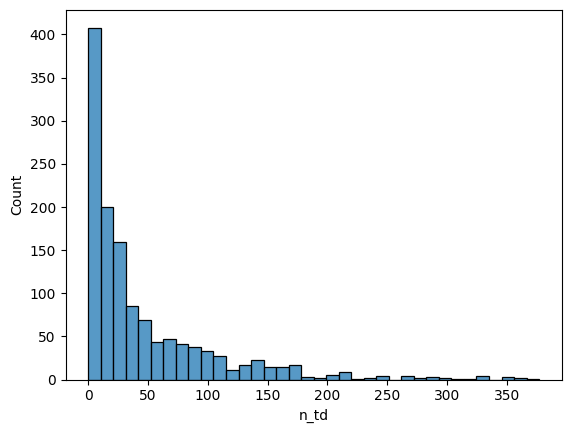

In [16]:
sns.histplot(data, x='n_td')

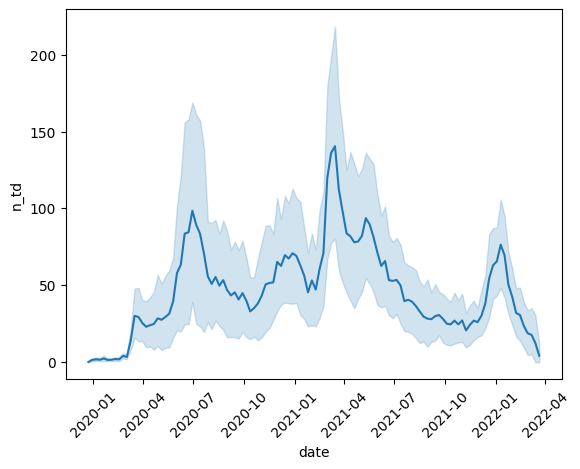

In [17]:
sns.lineplot(data, x='date', y='n_td')
plt.xticks(rotation=45);

Q1 2021 to end of Q3 2021 seems like it has good variability and includes an outbreak

## hiding the data to model

In [18]:
cutoff_date = pd.Timestamp('2021-03-29')
T_cutoff = data.loc[data['date'] == cutoff_date, 't'].iloc[0]
print(f"T_cutoff = {T_cutoff}, with {T_cutoff} weeks of training history")

T_cutoff = 67, with 67 weeks of training history


In [19]:
data['n_td_true'] = data['n_td']
data['observed']  = (data['t'] + data['d']) <= T_cutoff
data.loc[~data['observed'], 'n_td'] = np.nan

In [20]:
print(data['observed'].value_counts())
print(f"Cells to nowcast: {(~data['observed']).sum()}")

observed
True     682
False    616
Name: count, dtype: int64
Cells to nowcast: 616


In [21]:
data = data[data['t'] <= T_cutoff].copy()
print(data['observed'].value_counts())

observed
True     682
False     55
Name: count, dtype: int64


In [22]:
data

,date,t,d,week_of_year,n_td,n_td_true,observed
0,2019-12-23,1,0,52,0.0,0,True
1,2019-12-23,1,1,52,1.0,1,True
2,2019-12-23,1,2,52,0.0,0,True
3,2019-12-23,1,3,52,1.0,1,True
4,2019-12-23,1,4,52,0.0,0,True
...,...,...,...,...,...,...,...
732,2021-03-29,67,6,13,NaN,43,False
733,2021-03-29,67,7,13,NaN,49,False
734,2021-03-29,67,8,13,NaN,35,False
735,2021-03-29,67,9,13,NaN,32,False


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 737 entries, 0 to 736
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          737 non-null    datetime64[ns]
 1   t             737 non-null    int64         
 2   d             737 non-null    int64         
 3   week_of_year  737 non-null    int64         
 4   n_td          682 non-null    float64       
 5   n_td_true     737 non-null    int64         
 6   observed      737 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(4)
memory usage: 41.0 KB


# export

In [24]:
data.to_csv('../data/modelling_data.csv', index=False)

## model

In [25]:
pred = pd.read_csv('../data/model_pred.csv')

In [26]:
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737 entries, 0 to 736
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          737 non-null    object 
 1   t             737 non-null    int64  
 2   d             737 non-null    int64  
 3   week_of_year  737 non-null    int64  
 4   n_td          682 non-null    float64
 5   n_td_true     737 non-null    int64  
 6   observed      737 non-null    bool   
 7   pred          737 non-null    float64
dtypes: bool(1), float64(2), int64(4), object(1)
memory usage: 41.1+ KB


In [27]:
true_pred = pred.groupby('date')[['n_td_true', 'pred', 'observed']].sum().reset_index()
true_pred

,date,n_td_true,pred,observed
0,2019-12-23,2,12.467215,11
1,2019-12-30,17,14.845640,11
2,2020-01-06,21,14.863198,11
3,2020-01-13,18,14.834649,11
4,2020-01-20,27,14.822819,11
...,...,...,...,...
62,2021-03-01,1319,875.307825,5
63,2021-03-08,1498,1100.230458,4
64,2021-03-15,1545,1261.193056,3
65,2021-03-22,1235,1227.214491,2


In [28]:
true_pred[true_pred['observed'] < 11]

,date,n_td_true,pred,observed
57,2021-01-25,500,604.868764,10
58,2021-02-01,585,564.250941,9
59,2021-02-08,520,551.987322,8
60,2021-02-15,667,588.840156,7
61,2021-02-22,781,693.835952,6
62,2021-03-01,1319,875.307825,5
63,2021-03-08,1498,1100.230458,4
64,2021-03-15,1545,1261.193056,3
65,2021-03-22,1235,1227.214491,2
66,2021-03-29,1075,985.514080,1


Text(0.5, 1.0, 'Predicted vs True Total Cases')

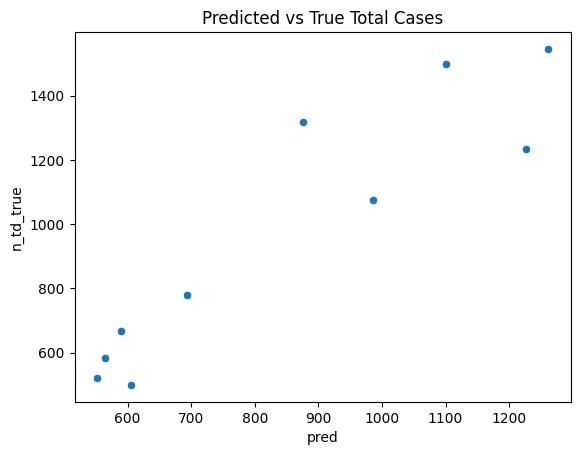

In [29]:
sns.scatterplot(data=true_pred[true_pred['observed'] < 11], y='n_td_true', x='pred')
plt.title('Predicted vs True Total Cases')

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Per-week totals
pred['n_td_filled'] = pred['n_td_true'].where(pred['observed'], pred['pred'])

weekly = pred.groupby('date').agg(
    eventual = ('n_td_true', 'sum'),
    nowcast  = ('n_td_filled', 'sum'),
).reset_index()

# Identify which weeks contain ANY hidden cells (the nowcast region)
nowcast_weeks = pred.loc[~pred['observed'], 'date'].unique()
weekly['is_nowcast'] = weekly['date'].isin(nowcast_weeks)

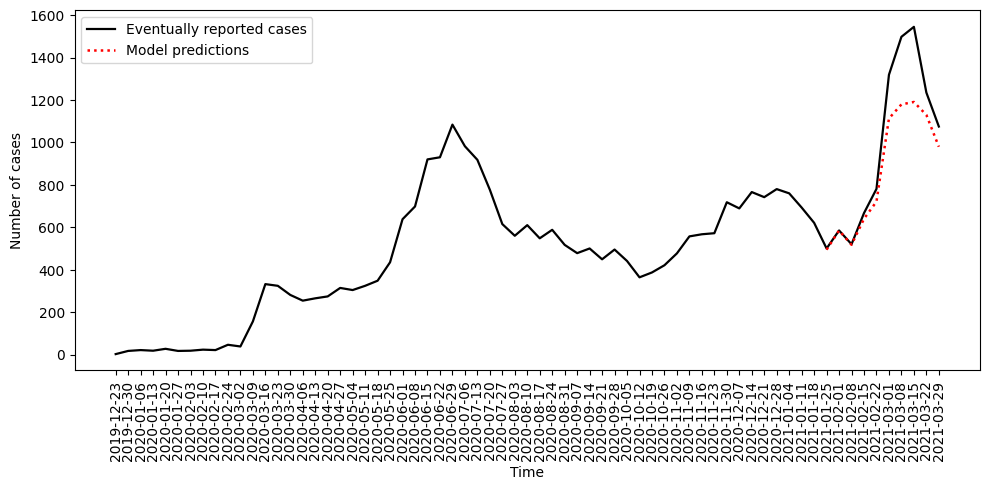

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

# Eventually reported: solid black across the whole series
ax.plot(weekly['date'], weekly['eventual'],
        color='black', linewidth=1.6, label='Eventually reported cases')

# Model predictions: dotted black, only over the nowcast window
nc = weekly[weekly['is_nowcast']]
ax.plot(nc['date'], nc['nowcast'],
        color='red', linestyle=':', linewidth=1.8, label='Model predictions')

ax.set_xlabel('Time')
ax.set_ylabel('Number of cases')
ax.legend(loc='upper left', frameon=True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

- seasonal cycle (assumption of yearly - same)
  - magnitude?
  - timing?
  - other covariates impacting?
  - 2 years enough?
  - seasonal cycle is not reliable, therefore do not usually include
- uncertainty
  - you can do inference as the bayesian (in mgcv)
  - log paper
    - 2.1 bayesian interpretation of GAMs
      - mgcv package
        - rmvn
      - code (10.5281/zenodo.15281264)
- LEO is keen on
  - model to understand the slope of the GAM (rate of change)
    - rate of change will be a good indicator of peak
    - using that to input into another model (time-series) correlated structure of the data
    - or another model that allows you to estimate parameters of the slope into the second model input
  - take a look at the literature, see if there is anything similar
    - are there rate of change models
    - is there something in ocean waves and estimating the slope up and down

# regimes

Goals:
  - Identify markers for 3 specific regimes
    - Outbreak
    - Baseline
    - Elimination
  - For the 3 regimes, need to find 2-3 samples of them in the data for testing and comparison


# models

## Regime (outbreak) - sample 1

In [36]:
gam_weekly = pd.read_csv('../data/gam_nowcast_summary.csv', parse_dates=["date"])
inla_weekly = pd.read_csv('../data/inla_nowcast_summary.csv', parse_dates=["date"])

In [41]:
df = pd.read_csv("../data/modelling_data.csv", parse_dates=["date"])
weekly_truth_naive = (
    df.groupby("date")
      .agg(N_true  = ("n_td_true", "sum"),N_naive = ("n_td", lambda x: x.sum(skipna=True))).reset_index())

weekly_truth_naive.to_csv("../data/weekly_truth_naive.csv", index=False)

### GAM

In [42]:
plot_data = weekly_truth_naive.merge(gam_weekly, on="date")

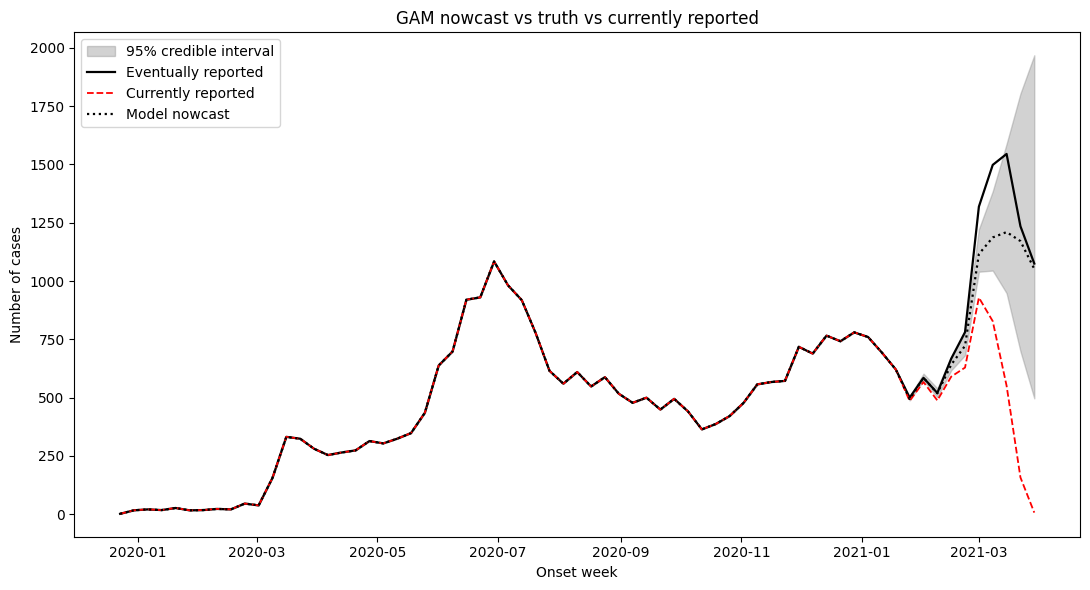

In [44]:
fig, ax = plt.subplots(figsize=(11, 6))

# Credible interval band
ax.fill_between(plot_data["date"], plot_data["N_lo"], plot_data["N_hi"],
                 color="grey", alpha=0.35, label="95% credible interval")

# Truth
ax.plot(plot_data["date"], plot_data["N_true"],
        color="black", linewidth=1.6, label="Eventually reported")

# Naive
ax.plot(plot_data["date"], plot_data["N_naive"],
        color="red", linestyle="--", linewidth=1.3, label="Currently reported")

# GAM nowcast
ax.plot(plot_data["date"], plot_data["N_hat"],
        color="black", linestyle=":", linewidth=1.6, label="Model nowcast")

ax.set_xlabel("Onset week")
ax.set_ylabel("Number of cases")
ax.set_title("GAM nowcast vs truth vs currently reported")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

### INLA

In [48]:
plot_data = weekly_truth_naive.merge(inla_weekly, on="date")

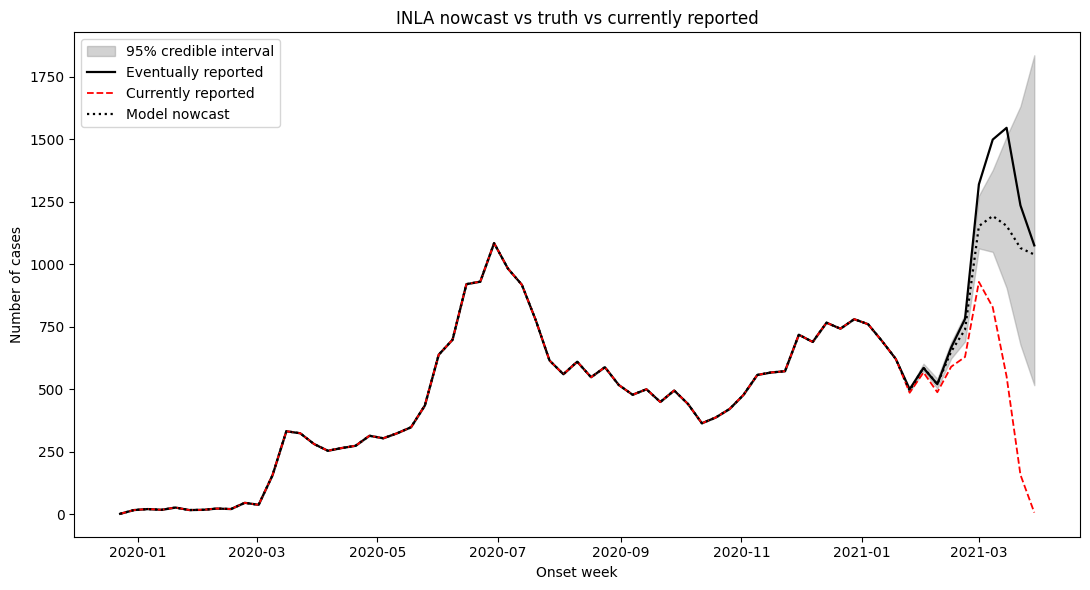

In [49]:
fig, ax = plt.subplots(figsize=(11, 6))

# Credible interval band
ax.fill_between(plot_data["date"], plot_data["N_lo"], plot_data["N_hi"],
                 color="grey", alpha=0.35, label="95% credible interval")

# Truth
ax.plot(plot_data["date"], plot_data["N_true"],
        color="black", linewidth=1.6, label="Eventually reported")

# Naive
ax.plot(plot_data["date"], plot_data["N_naive"],
        color="red", linestyle="--", linewidth=1.3, label="Currently reported")

# GAM nowcast
ax.plot(plot_data["date"], plot_data["N_hat"],
        color="black", linestyle=":", linewidth=1.6, label="Model nowcast")

ax.set_xlabel("Onset week")
ax.set_ylabel("Number of cases")
ax.set_title("INLA nowcast vs truth vs currently reported")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

# MEM

In [4]:
data = df.copy()
data = process_to_triangle(data, 10)

data = to_mem_format(data, date_col='date', value_col='n_td')
data


Kept 60749 / 65366 cases with Delay ≤ 10, 92.9%


,Season_2020,Season_2021
epiweek,,
1,17.0,760.0
2,21.0,693.0
3,18.0,621.0
4,27.0,500.0
5,17.0,585.0
6,18.0,520.0
7,23.0,667.0
8,21.0,781.0
9,46.0,1319.0


In [9]:
export(data, 'mem_fit_input')

executed, file mem_fit_input saved


In [12]:
data = df.copy()
data = process_to_triangle(data, 10)


Kept 60749 / 65366 cases with Delay ≤ 10, 92.9%


In [13]:
data

,date,t,d,week_of_year,n_td
0,2019-12-23,1,0,52,0
1,2019-12-23,1,1,52,1
2,2019-12-23,1,2,52,0
3,2019-12-23,1,3,52,1
4,2019-12-23,1,4,52,0
...,...,...,...,...,...
1293,2022-03-21,118,6,12,0
1294,2022-03-21,118,7,12,0
1295,2022-03-21,118,8,12,0
1296,2022-03-21,118,9,12,0


In [15]:
weekly = data.groupby('date', as_index=False)['n_td'].sum()
weekly

,date,n_td
0,2019-12-23,2
1,2019-12-30,17
2,2020-01-06,21
3,2020-01-13,18
4,2020-01-20,27
...,...,...
113,2022-02-21,260
114,2022-02-28,208
115,2022-03-07,196
116,2022-03-14,137


In [20]:
def classify_phase(weekly, window=3):
    """
    weekly_df must have columns: date, N_t (sorted by date)
    """
    weekly = weekly.sort_values('date').copy()
    weekly['trend'] = weekly['n_td'].diff(window)  # change over `window` weeks
    weekly['phase'] = weekly['trend'].apply(
        lambda x: 'rising' if x > 0 else 'declining' if x < 0 else 'stable'
    )
    return weekly

In [21]:
weekly = classify_phase(weekly)

In [22]:
weekly

,date,n_td,trend,phase
0,2019-12-23,2,NaN,stable
1,2019-12-30,17,NaN,stable
2,2020-01-06,21,NaN,stable
3,2020-01-13,18,16.0,rising
4,2020-01-20,27,10.0,rising
...,...,...,...,...
113,2022-02-21,260,-207.0,declining
114,2022-02-28,208,-145.0,declining
115,2022-03-07,196,-142.0,declining
116,2022-03-14,137,-123.0,declining
